# Customer Churn Prediction.

## Exploratory Data Analysis (EDA).

En esta fase del proyecto se realiza un análisis exploratorio de datos con el objetivo de identificar patrones, relaciones y variables asociadas al abandono de clientes (*customer churn*).

El análisis permitirá:

* Comprender el comportamiento de las variables.
* Detectar posibles relaciones con la variable objetivo.
* Identificar patrones de clientes con mayor riesgo de abandono.
* Obtener insights útiles desde una perspectiva de negocio.

## Importamos librerías.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
os.makedirs(
    r"..\images",
    exist_ok=True
)

## Cargamos el dataset procesado.

In [3]:
df = pd.read_csv(r"..\Data\Interim\telco_churn_cleaned_step1.csv")

## Vista general del dataset.

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
df.shape

(7043, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Análisis de la variable objetivo.

## Distribución de churn.

Analizamos la distribución de la variable objetivo (`Churn`) para comprobar la proporción de clientes que abandonan el servicio frente a aquellos que permanecen.

Este análisis permite detectar posibles problemas de desbalanceo que podrían afectar al entrenamiento de modelos de machine learning.

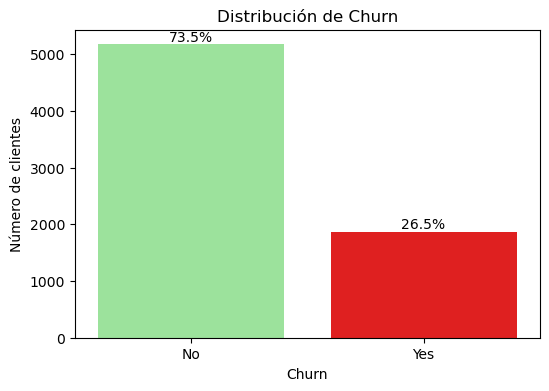

In [7]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=df['Churn'].map({0:'No', 1:'Yes'}),
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red'],
    legend=False
)

plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')

total = len(df)

for bar in ax.patches:
    percentage = f'{100 * bar.get_height() / total:.1f}%'
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.savefig(
    r"..\images\churn_distribution.png",
    bbox_inches='tight'
)

plt.show()

## Porcentaje de churn.

In [8]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## Observaciones iniciales sobre churn.

El dataset presenta un desbalance moderado entre clientes que abandonan el servicio y clientes que permanecen.

Este aspecto deberá tenerse en cuenta durante la fase de modelado y evaluación, especialmente en la selección de métricas adecuadas.

# Análisis de variables numéricas.

## Variables numéricas del dataset.

In [9]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

## Distribución de tenure.

La variable `tenure` representa la antigüedad del cliente en meses.

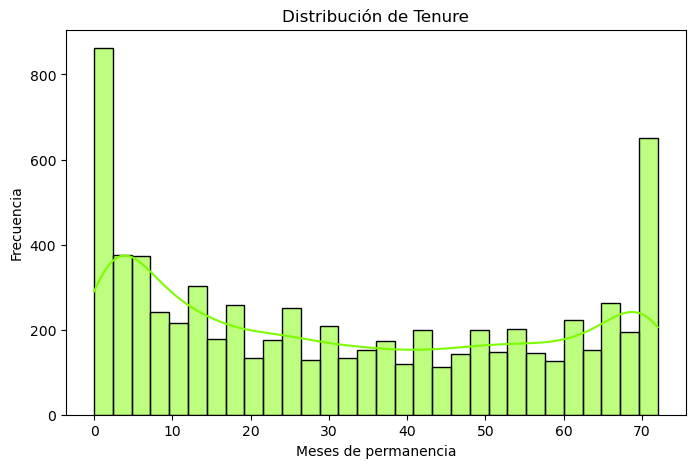

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True, color = 'lawngreen')

plt.title('Distribución de Tenure')
plt.xlabel('Meses de permanencia')
plt.ylabel('Frecuencia')

plt.show()

## Distribución de MonthlyCharges.

La variable `MonthlyCarges` representa el cargo mensual que paga cada cliente por los servicios contratados en dólares.

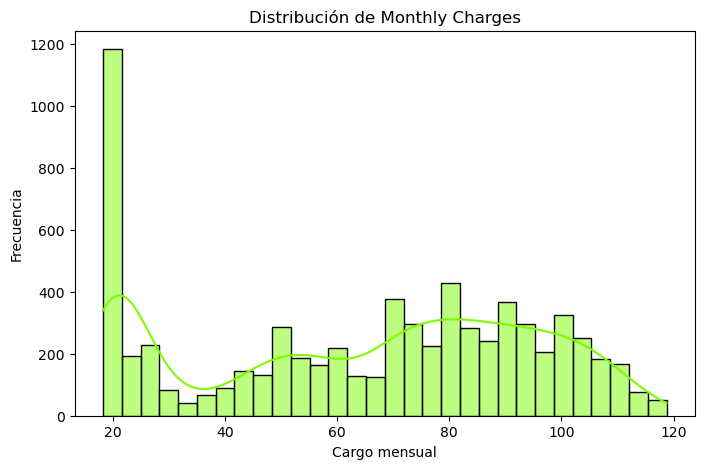

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color = 'lawngreen')

plt.title('Distribución de Monthly Charges')
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')

plt.show()

## Distribución de TotalCharges.

La variable `TotalCharges` representa el total acumulado que ha pagado un cliente en dólares desde que contrató el servicio hasta la fecha.

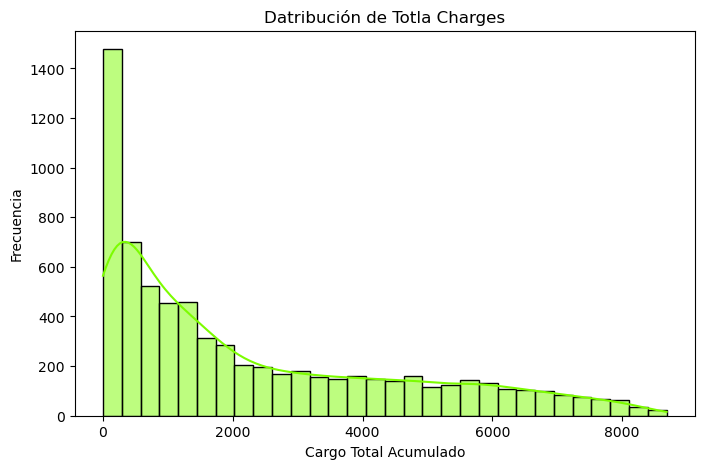

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'], bins=30, kde=True, color = 'lawngreen')

plt.title('Datribución de Totla Charges')
plt.xlabel('Cargo Total Acumulado')
plt.ylabel('Frecuencia')

plt.show()

# Relación entre variables numéricas y churn.

## Tenure vs Churn.

Se analiza la relación entre la antigüedad del cliente (`tenure`) y el abandono del servicio (`Churn`) mediante un boxplot.

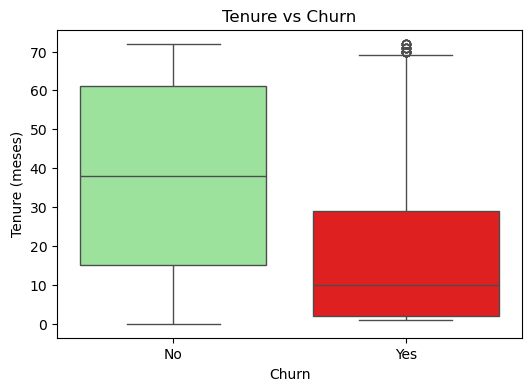

In [13]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    x=df['Churn'].map({0:'No', 1:'Yes'}),
    y=df['tenure'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (meses)')

plt.savefig(
    r"..\images\tenure_vs_churn.png",
    bbox_inches='tight'
)

plt.show()

Se observa una relación inversa entre la antigüedad del cliente (`tenure`) y la probabilidad de cancelación (`Churn`).

Los clientes que abandonan el servicio presentan, en promedio, una antigüedad significativamente menor que aquellos que permanecen en la compañía, lo que sugiere que el riesgo de churn es mayor durante las primeras etapas de la relación con el cliente.

También se observan algunos clientes con elevada antigüedad que finalmente abandonan el servicio.

Estos casos podrían indicar situaciones específicas no reflejadas directamente en el dataset, como cambios en las necesidades del cliente, insatisfacción acumulada o aparición de ofertas competitivas.

## MonthlyCharges vs Churn.

Se analiza la relación entre los cargos mensuales (`MonthlyCharges`) y el abandono del servicio.

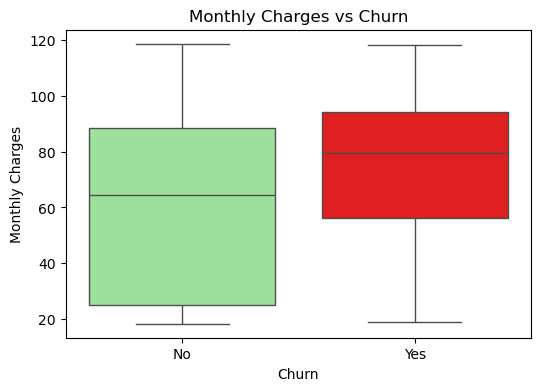

In [14]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    x=df['Churn'].map({0:'No', 1:'Yes'}),
    y=df['MonthlyCharges'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.savefig(
    r"..\images\monthlycharges_vs_churn.png",
    bbox_inches='tight'
)

plt.show()

Se observa que los clientes que cancelan el servicio (`Churn = Yes`) presentan, en promedio, cargos mensuales (`MonthlyCharges`) más elevados que aquellos que permanecen como clientes activos.

Esto sugiere que el coste mensual del servicio podría ser un factor relevante en la decisión de cancelación. Los clientes con planes más costosos parecen mostrar una mayor propensión al abandono, posiblemente debido a una percepción insuficiente del valor recibido en relación con el precio pagado.

## TotalCharges vs Churn.

Se analiza la relación entre el gasto total acumulado (`TotalCharges`) y el abandono del servicio.

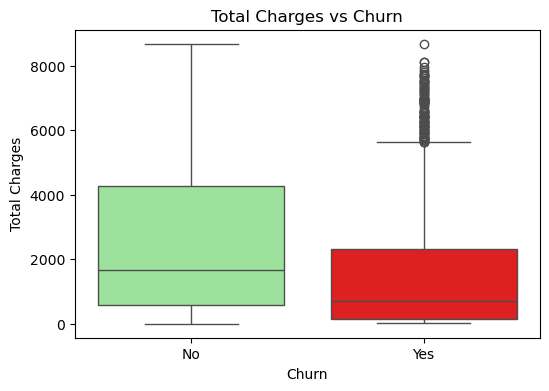

In [15]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(
    x=df['Churn'].map({0:'No', 1:'Yes'}),
    y=df['TotalCharges'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.title('Total Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

Se observa que los clientes que permanecen en la compañía (`Churn = No`) presentan, en general, valores de `TotalCharges` significativamente más elevados que aquellos que cancelan el servicio (`Churn = Yes`).

Este comportamiento resulta coherente con el análisis previo de la variable `tenure`, ya que los clientes con mayor antigüedad tienden a acumular un gasto total más elevado a lo largo del tiempo.

Asimismo, se observan algunos valores extremos en clientes que abandonan el servicio. Sin embargo, estos registros parecen coherentes desde una perspectiva de negocio, ya que podrían corresponder a clientes con larga permanencia o alto nivel de consumo antes de cancelar el servicio.

Por este motivo, en esta fase del análisis exploratorio no se considera necesario eliminar dichos valores.

# Análisis de variables categóricas.

## Variables categóricas.

In [16]:
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

## Contract vs Churn.

Se analiza la relación entre el tipo de contrato (`Contract`) y el abandono del servicio.

El tipo de contrato puede ser uno de los factores más relevantes para la retención de clientes.

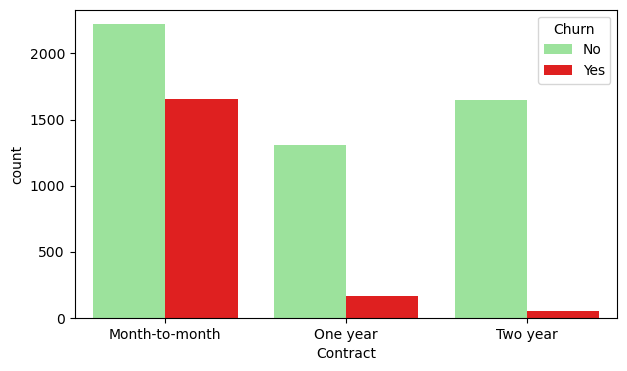

In [17]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    x=df['Contract'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.savefig(
    r"..\images\contract_vs_churn.png",
    bbox_inches='tight'
)

plt.show()

Los clientes con contratos mensuales presentan una tasa de abandono significativamente superior a los clientes con contratos de uno o dos años.

Esto sugiere que los contratos de larga duración contribuyen a la retención de clientes.

## InternetService vs Churn.

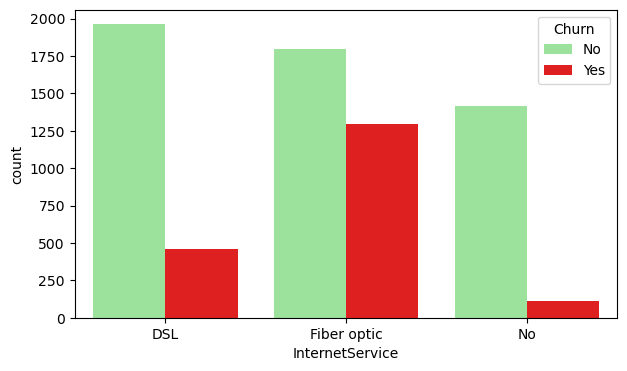

In [18]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    x=df['InternetService'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.savefig(
    r"..\images\internetservice_vs_churn.png",
    bbox_inches='tight'
)

plt.show()

Los clientes con servicio de fibra óptica presentan una mayor proporción de churn respecto a otros tipos de servicio.

## PaymentMethod vs Churn.

Se analiza la relación entre el método de pago (`PaymentMethod`) y el abandono del servicio.

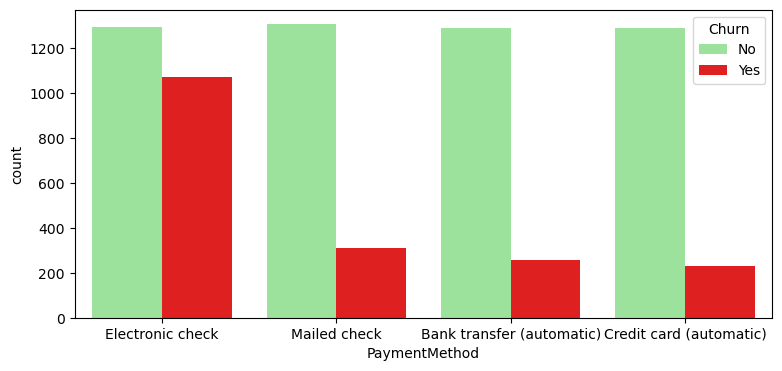

In [19]:
plt.figure(figsize=(9,4))

ax = sns.countplot(
    x=df['PaymentMethod'],
    hue=df['Churn'].map({0:'No', 1:'Yes'}),
    palette=['lightgreen', 'red']
)

plt.show()

Algunos métodos de pago muestran mayores tasas de abandono que otros, especialmente los pagos electrónicos automáticos.

Esto podría indicar diferencias de comportamiento entre segmentos de clientes.

## Gender vs Churn.

Se analiza la relación entre el género del cliente (`gender`) y el abandono del servicio.

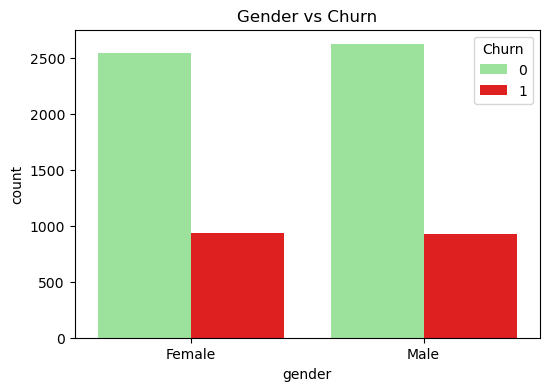

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df,
             palette=['lightgreen', 'red'])
plt.title('Gender vs Churn')

plt.show()

No se observan diferencias especialmente significativas entre géneros respecto al abandono del servicio.

## Partner vs Churn.

Se analiza la relación entre la existencia de pareja (Partner) y el abandono del servicio.

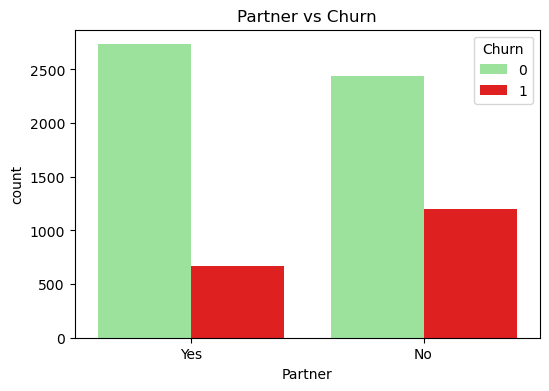

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df,
             palette=['lightgreen', 'red'])
plt.title('Partner vs Churn')

plt.show()

Los clientes que cuentan con pareja presentan una menor tendencia al abandono en comparación con aquellos que no tienen pareja

## Dependents vs Churn.

Se analiza la relación entre clientes con dependientes (Dependents) y el abandono del servicio.

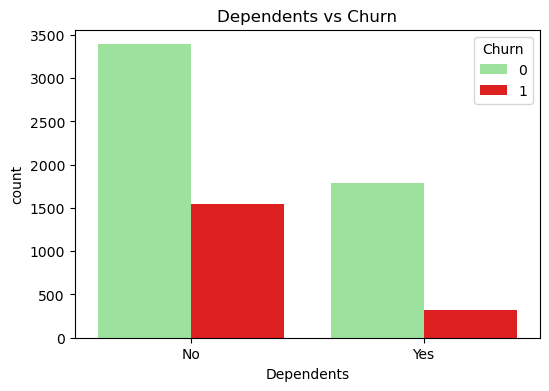

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df,
             palette=['lightgreen', 'red'])
plt.title('Dependents vs Churn')

plt.show()

Los clientes con dependientes muestran una mayor estabilidad y menores tasas de abandono respecto a clientes sin dependientes.

# Matriz de correlación.

## Correlación entre variables numéricas.

Se analiza la correlación entre las variables numéricas del dataset para identificar relaciones lineales relevantes.

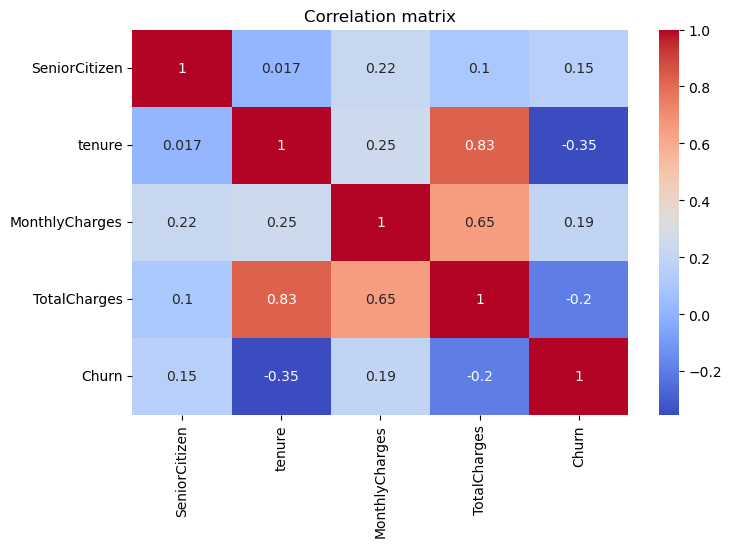

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')

plt.savefig(
    r"..\images\correlation_matrix.png",
    bbox_inches='tight'
)

plt.show()

Se observa que `tenure` presenta la correlación negativa más fuerte con `Churn`, lo que sugiere que los clientes con mayor antigüedad tienen menor probabilidad de abandonar el servicio. Por otro lado, `MonthlyCharges` muestra una correlación positiva moderada, indicando que clientes con cargos mensuales más elevados presentan una mayor tendencia al churn.

Asimismo, se aprecia una correlación elevada entre `tenure` y `TotalCharges`, un comportamiento coherente desde una perspectiva de negocio, ya que clientes con más tiempo en la compañía tienden a acumular un mayor gasto total.

# Principales insights del análisis exploratorio.

A partir del análisis exploratorio realizado se identifican varios patrones relevantes asociados al abandono de clientes:

- Los clientes con menor antigüedad (`tenure`) presentan una mayor probabilidad de cancelar el servicio, especialmente durante los primeros meses de contratación.

- Los contratos mensuales (`Month-to-month`) muestran tasas de churn significativamente superiores respecto a contratos de larga duración.

- Los clientes con cargos mensuales (`MonthlyCharges`) más elevados presentan una mayor tendencia al abandono, lo que podría indicar sensibilidad al precio o una percepción insuficiente del valor recibido.

- Los clientes con mayor gasto acumulado (`TotalCharges`) tienden a permanecer más tiempo en la compañía, mostrando un comportamiento más estable.

- El servicio de fibra óptica (`Fiber optic`) presenta una proporción de churn superior a otros tipos de servicio de internet.

- Variables como `Partner` y `Dependents` parecen estar asociadas a una mayor estabilidad y menor propensión al abandono.

- Se detecta una correlación elevada entre `tenure` y `TotalCharges`, aspecto que deberá considerarse durante la fase de modelado para evitar posibles problemas de multicolinealidad en modelos lineales.

En conjunto, estos hallazgos proporcionan información útil tanto para la construcción de modelos predictivos como para el diseño de estrategias de retención de clientes.

# Guardado del dataset para la fase de preprocesamiento.

In [24]:
os.makedirs(r"..\Data\Processed", exist_ok=True)

df.to_csv(
    r"..\Data\Processed\telco_churn_eda_completed.csv",
    index=False
)

# Conclusiones.

En esta fase del proyecto se realizó un análisis exploratorio de datos orientado a comprender los factores asociados al abandono de clientes.

El análisis permitió identificar variables con posible capacidad predictiva y obtener insights relevantes desde una perspectiva de negocio.

Los resultados obtenidos servirán como base para la siguiente fase del proyecto, centrada en el preprocesamiento y preparación de los datos para el entrenamiento de modelos de machine learning.